# Change im mRS between discharge and follow-up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('./data/SAMueL ssnap extract v2.csv', low_memory=False)


In [3]:
# save
with_data_stats = data[data['S8Rankin6Month'].notnull()].describe(include='all')
without_data_stats = data[data['S8Rankin6Month'].isnull()].describe(include='all')

stats = pd.concat(
    {'with_S8Rankin6Month': with_data_stats, 'without_S8Rankin6Month': without_data_stats},
    names=['group']
)
stats.T.to_csv('./output/descriptive_stats_s8rankin6month.csv', index=True)
stats.T

group                                    with_S8Rankin6Month         \
                                                       count unique   
PatientId                                           109723.0    NaN   
ProClinV1Id                                         109723.0    NaN   
TeamName                                              109723    120   
AgeUnder40                                          109723.0    NaN   
Age40to44                                           109723.0    NaN   
...                                                      ...    ...   
ArrivalPatientLocationtoArrivalMinutes               34153.0    NaN   
DeparturePatientLocationtoArrivalMinutes             34120.0    NaN   
WheelsStoptoArrivalMinutes                           28273.0    NaN   
MobileDatatoArrivalMinutes                            6120.0    NaN   
S1PreHospitalImpression                                34104     24   

group                                                                      \
                                                                      top   
PatientId                                                             NaN   
ProClinV1Id                                                           NaN   
TeamName                                  Royal Stoke University Hospital   
AgeUnder40                                                            NaN   
Age40to44                                                             NaN   
...                                                                   ...   
ArrivalPatientLocationtoArrivalMinutes                                NaN   
DeparturePatientLocationtoArrivalMinutes                              NaN   
WheelsStoptoArrivalMinutes                                            NaN   
MobileDatatoArrivalMinutes                                            NaN   
S1PreHospitalImpression                                                FP   

group                                                            \
                                           freq            mean   
PatientId                                   NaN  1064664.663425   
ProClinV1Id                                 NaN  1070313.106796   
TeamName                                   3223             NaN   
AgeUnder40                                  NaN        0.015412   
Age40to44                                   NaN        0.013753   
...                                         ...             ...   
ArrivalPatientLocationtoArrivalMinutes      NaN    -1944.713788   
DeparturePatientLocationtoArrivalMinutes    NaN   -70784.912984   
WheelsStoptoArrivalMinutes                  NaN  -291798.999363   
MobileDatatoArrivalMinutes                  NaN        0.503431   
S1PreHospitalImpression                   24317             NaN   

group                                                                 \
                                                     std         min   
PatientId                                  346518.232818     16663.0   
ProClinV1Id                                347923.132701     16663.0   
TeamName                                             NaN         NaN   
AgeUnder40                                      0.123183         0.0   
Age40to44                                       0.116464         0.0   
...                                                  ...         ...   
ArrivalPatientLocationtoArrivalMinutes     345351.677166 -63822461.0   
DeparturePatientLocationtoArrivalMinutes  2118705.465455 -64049234.0   
WheelsStoptoArrivalMinutes                4293066.243114 -64004735.0   
MobileDatatoArrivalMinutes                   1830.686495    -15652.0   
S1PreHospitalImpression                              NaN         NaN   

group                                                                     ...  \
                                               25%        50%        75%  ...   
PatientId                                 768518.0  1080644.0  1361754.5  ...   
ProClinV1Id           

In [4]:
# Compare thrombolysis rates between those with and without 6-month mRS data

# Convert thrombolysis field to numeric (1=yes, 0=no)
thrombolysis_map = {'Y': 1, 'N': 0, 'NB': 0}
thrombolysis_numeric = (
    data['S2Thrombolysis']
    .astype(str)
    .str.strip()
    .str.upper()
    .map(thrombolysis_map)
)

thrombolysis_rates = (
    data.assign(S2Thrombolysis_num=thrombolysis_numeric)
        .groupby(data['S8Rankin6Month'].notnull())['S2Thrombolysis_num']
        .mean()
        .rename(index={True: 'with_6m_mrs', False: 'without_6m_mrs'})
)

thrombolysis_rates

S8Rankin6Month
without_6m_mrs    0.112843
with_6m_mrs       0.117368
Name: S2Thrombolysis_num, dtype: float64

In [5]:
mrs = data[['S2RankinBeforeStroke', 'S7RankinDischarge', 'S8Rankin6Month']]

In [6]:
mrs.describe()

,S2RankinBeforeStroke,S7RankinDischarge,S8Rankin6Month
count,360381.000000,357805.000000,109723.000000
mean,1.033209,2.649608,2.177091
std,1.372371,1.919569,1.807369
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000
50%,0.000000,2.000000,2.000000
75%,2.000000,4.000000,3.000000
max,5.000000,6.000000,6.000000


In [7]:
# Limit to patients with mRS at discharge and 6 month follow up
mrs_change = mrs[(~mrs['S7RankinDischarge'].isna()) & (~mrs['S8Rankin6Month'].isna())]
mrs_change['change_from_discharge'] = mrs_change['S8Rankin6Month'] - mrs_change['S7RankinDischarge']
mrs_change['absolute_change_from_discharge'] = abs(mrs_change['change_from_discharge'])

/tmp/ipykernel_14310/151780863.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mrs_change['change_from_discharge'] = mrs_change['S8Rankin6Month'] - mrs_change['S7RankinDischarge']
/tmp/ipykernel_14310/151780863.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mrs_change['absolute_change_from_discharge'] = abs(mrs_change['change_from_discharge'])


In [8]:
mrs_change.describe()
# save the dataframe
mrs_change.describe().to_csv('./output/mrs_change_from_discharge.csv', index=True)

/tmp/ipykernel_14310/4045489601.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mrs_change['improvement_from_discharge'] = mrs_change['change_from_discharge'] * -1
/tmp/ipykernel_14310/4045489601.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])


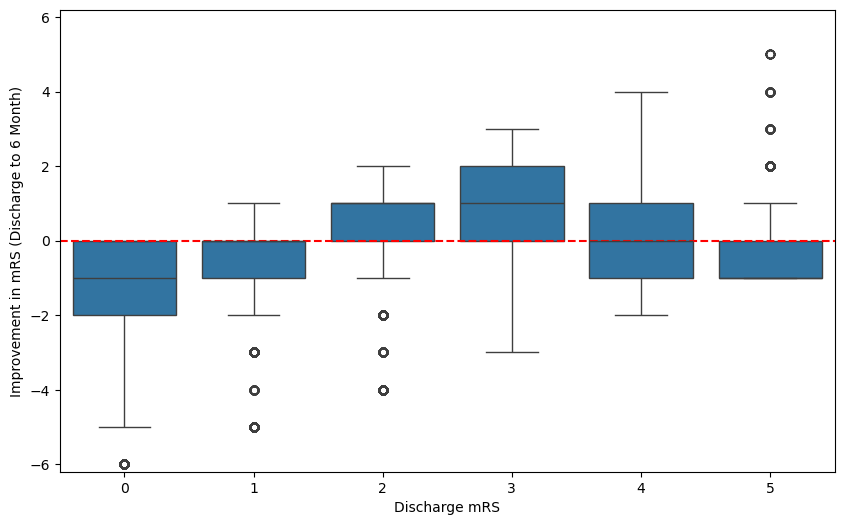

In [9]:
# Plot change from discharge for each level of discharge mRS
fig, ax = plt.subplots(figsize=(10, 6))
mrs_change['improvement_from_discharge'] = mrs_change['change_from_discharge'] * -1
sns.boxplot(x='S7RankinDischarge', y='improvement_from_discharge', data=mrs_change, ax=ax)

plt.xlabel('Discharge mRS')
plt.ylabel('Improvement in mRS (Discharge to 6 Month)')
plt.axhline(0, color='red', linestyle='--')

# Set x-axis tick labels as integers
ax.set_xticklabels([str(int(float(t.get_text()))) for t in ax.get_xticklabels()])

# Set ylim -6 to 6
plt.ylim(-6.2, 6.2)

# Save the plot
plt.savefig('./mrs_change_from_discharge.png')
plt.show()

In [11]:
# Create table of improvement by discharge mRS - include mean, median, quartiles, and count
improvement_stats = (
    mrs_change.groupby('S7RankinDischarge')['improvement_from_discharge']
        .agg(['mean', 'median', 'count', 'std', 'min', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'max'])
        .rename(columns={'mean': 'mean', 'median': 'median', 'count': 'count', 'std': 'std_dev', 'min': 'min', '<lambda_0>': '25%', '<lambda_1>': '75%', 'max': 'max'})
)
improvement_stats

,mean,median,count,std_dev,min,25%,75%,max
S7RankinDischarge,,,,,,,,
0.0,-1.151602,-1.0,16108,1.318705,-6.0,-2.0,0.0,-0.0
1.0,-0.400714,-0.0,28020,1.321115,-5.0,-1.0,0.0,1.0
2.0,0.226490,1.0,24681,1.419303,-4.0,0.0,1.0,2.0
3.0,0.491189,1.0,20996,1.589519,-3.0,-0.0,2.0,3.0
4.0,0.213142,-0.0,13803,1.613883,-2.0,-1.0,1.0,4.0
5.0,-0.292232,-1.0,6115,1.109390,-1.0,-1.0,-0.0,5.0


In [ ]:
# Plot histogram of change from discharge
plt.figure(figsize=(10, 6))
sns.histplot(mrs_change['improvement_from_discharge'], bins=np.arange(-5.5, 5.5, 1), kde=False)
#plt.title('Distribution of Change in mRS from Discharge to 6 Month Follow-up')
plt.xlabel('Improvement in mRS (Discharge to 6 Month)')
plt.ylabel('Frequency')
# save the plot
plt.savefig('./mrs_change_from_discharge_histogram.png')
plt.show()

In [ ]:
# Create table to show the count of patients who improved, worsened, or stayed the same from discharge to 6 month follow-up
change_counts = mrs_change['change_from_discharge'].value_counts().sort_index()
change_counts_df = change_counts.reset_index()
change_counts_df.columns = ['change_from_discharge', 'count']
# Add percentage column
change_counts_df['percentage'] = (change_counts_df['count'] / change_counts_df['count'].sum()) * 100
change_counts_df['percentage'] = change_counts_df['percentage'].round(1)
change_counts_df.to_csv('./output/mrs_change_from_discharge_counts.csv', index=False)
change_counts_df